# Test the statistical method for different scenario

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

c0 = {
    "acc": "#941717",
    "cor": "#388E3C",
    "ggd": "#42A5F5",
    "wd": "#FFA000",
    "sum": "lightgrey",
}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square
from cstes import U

images_dir = "/Users/mdemol/ownCloud/PhD/images/images_methodo"

In [2]:
N = 100000  # nb coloc

__________________________
# 1. No errors
## 1.1. Gradient wind balance

$$u_{\theta} = -\frac{1}{2}fr \pm \frac{1}{2}fr\sqrt{1+\frac{4}{fr}u_g} $$

$$\frac{u_{\theta}^2}{r} + fu_{\theta} = g\partial_r\eta = fu_g$$

$$ \frac{4u_g}{fr}>-1 $$

$$u_g = \frac{fr}{4}[(\frac{2u_{\theta}}{fr}-1)^2-1]$$

In [3]:
def compute_u_theta(f, r, ug):
    a = -1 / 2 * f * r
    b = 1 / 2 * f * r * np.sqrt(1 + 4 * ug / f / r)
    return a - b, a + b


def compute_ug(f, r, utheta):
    return f * r / 4 * ((2 * utheta / f / r + 1) ** 2 - 1)

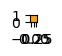

In [4]:
import numpy as np

# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return (
        1.0
        / (2.0 * np.pi * sx * sy)
        * np.exp(
            -((x - mx) ** 2.0 / (2.0 * sx**2.0) + (y - my) ** 2.0 / (2.0 * sy**2.0))
        )
    )


def create_champ(L=30e3, std=30e3, lat=40, dsl_amp=-3e-2):
    g = 9.81
    x = np.arange(-L, L, 1e3)
    y = np.arange(-L, L, 1e3)

    X, Y = np.meshgrid(x, y)  # get 2D variables instead of 1D
    z = gaus2d(X, Y, mx=0, my=0, sx=std, sy=std)
    z = z / z.max() * dsl_amp

    ds = xr.Dataset(
        data_vars=dict(
            eta=(["y", "x"], z),
        ),
        coords=dict(
            y=("y", y),
            x=("x", x),
        ),
    )

    ds["eta"] = ds["eta"].assign_attrs({"long_name": r"DSL $\eta$", "unit": "m"})
    ds["x"] = ds["x"].assign_attrs({"unit": "m"})
    ds["y"] = ds["y"].assign_attrs({"unit": "m"})

    f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
    ds["r"] = np.sqrt(ds.x**2 + ds.y**2)
    ds["cos"] = ds.x / ds.r
    ds["sin"] = ds.y / ds.r

    ds["dxeta"] = ds["eta"].differentiate("x")
    ds["dyeta"] = ds["eta"].differentiate("y")
    ds["dreta"] = ds.dxeta * ds.cos + ds.dyeta * ds.sin

    ds["ugx"] = g / f * ds.dyeta
    ds["ugy"] = -g / f * ds.dxeta
    ds["ug"] = g / f * ds.dreta

    def compute_u_theta(f, r, ug):
        a = -1 / 2 * f * r
        b = 1 / 2 * f * r * np.sqrt(1 + 4 * ug / f / r)
        return a - b, a + b

    ds["utheta0"] = compute_u_theta(f, ds.r, ds.ug)[0]
    ds["utheta1"] = compute_u_theta(f, ds.r, ds.ug)[1]
    ds["utheta1x"] = -ds.utheta1 * (ds.sin)
    ds["utheta1y"] = ds.utheta1 * (ds.cos)
    ds = ds.transpose("y", "x")

    ds["acc"] = ds.utheta1**2 / ds.r
    ds["cor"] = f * ds.utheta1
    ds["ggd"] = -g * ds.dreta

    ds["accx"] = ds.acc * (ds.cos)
    ds["accy"] = ds.acc * (ds.sin)
    ds["corx"] = ds.cor * (ds.cos)
    ds["cory"] = ds.cor * (ds.sin)
    ds["ggdx"] = ds.ggd * (ds.cos)
    ds["ggdy"] = ds.ggd * (ds.sin)
    # ds['corx'] = - f*ds.utheta1y
    # ds['cory'] = f*ds.utheta1x
    # ds['ggdx'] = -g*ds.dxeta
    # ds['ggdy'] = -g*ds.dyeta

    return ds


from diagnosis import compute_mean_square, put_fig_letter
from cstes import U2


def create_prod_exc_sum(df, null_mean):
    df = df.copy()
    ds = xr.Dataset()
    for direction in ["x", "y"]:
        if direction == "x":
            l = {"acc": "accx", "cor": "corx", "ggd": "ggdx", "wd": "wdx"}
        if direction == "y":
            l = {"acc": "accy", "cor": "cory", "ggd": "ggdy", "wd": "wdy"}

        if null_mean:
            for v in l:
                df[l[v]] = df[l[v]] - df[l[v]].mean()

        # sum
        ds["sum" + direction] = sum([df[l[v]] for v in l])

        # simple var + sum- one term
        for v in l:
            ds[l[v]] = df[l[v]]
            print(df[l[v]].mean())
            ds["exc" + direction + "_" + v] = ds["sum" + direction] - ds[l[v]]

        # 2 by 2 product
        import itertools

        couple = list(itertools.combinations(list(l.keys()), 2))
        for c in couple:
            ds["prod" + direction + "_" + "_".join(c)] = (
                ds[c[0] + direction] * ds[c[1] + direction]
            )
    return ds


def plot_diag(fig, ax, ds2):
    # labels = {'acc':r'$u_{\theta}^2/r$', 'cor':r'$fu_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    # labels = {'acc':r'$d_t\vec{u}$', 'cor':r'$f\vec{k}\wedge u_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    labels = {
        "acc": "Lagrangian acceleration",
        "cor": "Coriolis acceleration",
        "ggd": "Pressure gradient term",
        "wd": "Wind term",
        "sum": "Residual",
    }
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()
    var = ["acc", "cor", "ggd"]
    i = 0
    for v in var:
        # total MS
        # ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)
        w = 0.8
        # B and E
        if ds2["B_" + v] > 0:
            ax.bar(i, ds2["B_" + v], color=c0[v], width=w, label=labels[v])
            if ds2["E_" + v] < 0:
                ax.bar(i, ds2["E_" + v], color="lightgrey", width=w)
            else:
                ax.bar(
                    i, ds2["E_" + v], bottom=ds2["B_" + v], color="lightgrey", width=w
                )
        else:
            ax.bar(i, ds2["B_" + v], color=c0[v], width=w)
            if ds2["E_" + v] > 0:
                ax.bar(i, ds2["E_" + v], color="lightgrey", width=w)
            else:
                ax.bar(
                    i, ds2["E_" + v], bottom=ds2["B_" + v], color="lightgrey", width=w
                )

        # X
        w = 0.4
        X_var = [x for x in ds2 if (("X_" in x) & (v in x) & ("ser_" not in x))]
        pos_X = [x for x in X_var if ds2[x] > 0]
        neg_X = [x for x in X_var if x not in pos_X]

        sum_posX = 0
        for X in pos_X:
            xc = X.replace("X_", "").split("_")
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X] / 2, bottom=sum_posX, color=c0[xc[1]], hatch="/", width=w)
            sum_posX += ds2[X] / 2

        sum_negX = 0
        for X in neg_X:
            xc = X.replace("X_", "").split("_")
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X] / 2, bottom=sum_negX, color=c0[xc[1]], hatch="/", width=w)
            sum_negX += ds2[X] / 2
        i += 1
    # ax.bar(i, ds2['S'], color = 'lightgrey')
    ax.grid()
    # ax.legend()
    ax.set_ylabel(r"[$\gamma^2$]")


def plot_diag2(fig, ax, ds2):
    # labels = {'acc':r'$u_{\theta}^2/r$', 'cor':r'$fu_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    # labels = {'acc':r'$d_t\vec{u}$', 'cor':r'$f\vec{k}\wedge u_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    labels = {
        "acc": "Lagrangian acceleration",
        "cor": "Coriolis acceleration",
        "ggd": "Pressure gradient term",
        "wd": "Wind term",
        "sum": "Residual",
    }
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()

    plt.rcParams["hatch.color"] = c0["acc"]
    ax.bar(0, ds2["X_acc_cor"], color=c0["cor"], hatch="/")
    ax.bar(1, ds2["X_acc_ggd"], color=c0["ggd"], hatch="/")
    plt.rcParams["hatch.color"] = c0["cor"]
    ax.bar(2, ds2["X_cor_ggd"], color=c0["ggd"], hatch="/")
    ax.set_ylabel(r"[$\gamma^2$]")


fig, ax = plt.subplots(figsize=(0.1, 0.1))
ax.bar(0, 1, color=c0["acc"], label="Lagrangian acceleration")
ax.bar(0, 1, color=c0["cor"], label="Coriolis acceleration")
ax.bar(0, 1, color=c0["ggd"], label="Pressure gradient term")
ax.bar(0, 1, color=c0["wd"], label="Wind term")
# ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()

In [37]:
def eddy_reconstruction(L=25e3, std=10e3, dsl_amp=2e-2, R=0.5):  # Create eddy
    ds = create_champ(L, std, dsl_amp=dsl_amp)
    R = std * R
    # Coloc
    # random sampling
    # xa = np.random.uniform(-1, 1, 1000) * L
    # ya = np.random.uniform(-1, 1, 1000) * L

    # circle sampling
    xa = R * np.cos(np.linspace(0, 2 * np.pi, 10000))
    ya = R * np.sin(np.linspace(0, 2 * np.pi, 10000))

    dsa = ds.interp(x=("row_number", xa), y=("row_number", ya))

    ds["x"] = (ds.x / 1000).assign_attrs({"units": "km"})
    ds["y"] = (ds.y / 1000).assign_attrs({"units": "km"})
    dsa["x"] = (dsa.x / 1000).assign_attrs({"units": "km"})
    dsa["y"] = (dsa.y / 1000).assign_attrs({"units": "km"})

    dsa["wdx"] = dsa["acc"] / dsa["acc"] - 1
    dsa["wdy"] = dsa["acc"] / dsa["acc"] - 1

    # check for sampling
    # dsa=dsa.where(dsa.y>0, drop=True)

    dfa = dsa.to_dataframe()
    dsa_ = create_prod_exc_sum(dfa, null_mean=True)
    # dsa__ = create_prod_exc_sum(dfa, null_mean =False)

    # Reconstruction dataset
    dsm = compute_mean_square(dsa_, dirname=("x", "y")) / U2
    return ds, dsa, dsm

In [53]:
ds, dsa, dsm = eddy_reconstruction(L=25e3, std=10e3, dsl_amp=2e-2)

-8.673617379884036e-23
0.0
1.7347234759768072e-22
0.0
4.336808689942018e-23
1.7347234759768072e-22
3.4694469519536144e-22
0.0


nan
nan
nan
nan
nan
nan
nan
nan
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.7347234759768072e-22
-3.4694469519536144e-22
0.0
0.0
0.0
0.0
8.673617379884036e-23
0.0
8.673617379884036e-23
3.4694469519536144e-22
1.7347234759768072e-22
0.0
0.0
0.0
1.7347234759768072e-22
0.0
0.0
1.7347234759768072e-22
-3.4694469519536144e-22
0.0
-8.673617379884036e-23
0.0
1.7347234759768072e-22
0.0
-8.673617379884036e-23
0.0
1.7347234759768072e-22
0.0
4.336808689942018e-23
1.7347234759768072e-22
3.4694469519536144e-22
0.0
8.673617379884036e-23
0.0
1.7347234759768072e-22
0.0
8.673617379884036e-23
-3.4694469519536144e-22
0.0
0.0
1.7347234759768072e-22
0.0
0.0
0.0
-4.336808689942018e-23
3.4694469519536144e-22
3.4694469519536144e-22
0.0
0.0
6.938893903907229e-22
-3.4694469519536144e-22
0.0
-1.3010426069826052e-22
0.0
1.7347234759768072e-22
0.0
1.7347234759768072e-22
1.3877787807814457e-21
-1.0408340855860842e-21
0.0
4.336808689942018e-23
0.0
0.0
0.0
2.168404344971009e-22
0.0
3.4694469519536144e-22
0.0
8.673617379884036e-2

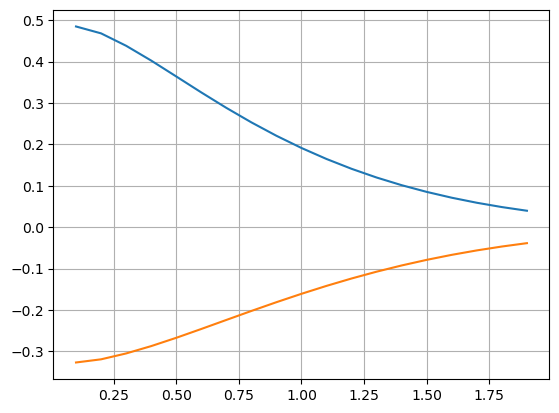

In [44]:
R_ = np.arange(0, 2, 0.1)
ratio1 = []
ratio2 = []
for r in R_:
    ds, dsa, dsm = eddy_reconstruction(R=r)
    ratio1.append(dsm.X_acc_cor / dsm.X_cor_ggd)
    ratio2.append(dsm.X_acc_ggd / dsm.X_cor_ggd)


plt.plot(R_, ratio1, label="X_acc_cor/X_cor_ggd")
plt.plot(R_, ratio2, label="X_acc_ggd/X_cor_ggd")
plt.grid()

0.0
-6.938893903907229e-22
-3.4694469519536144e-22
0.0
3.4694469519536144e-22
-3.4694469519536144e-22
-6.938893903907229e-22
0.0
0.0
0.0
3.4694469519536144e-22
0.0
-8.673617379884036e-23
-1.7347234759768072e-22
0.0
0.0
8.673617379884036e-23
1.7347234759768072e-22
-1.0408340855860842e-21
0.0
0.0
3.4694469519536144e-22
0.0
0.0
0.0
-1.7347234759768072e-22
1.7347234759768072e-22
0.0
2.168404344971009e-23
3.4694469519536144e-22
-1.7347234759768072e-22
0.0
4.336808689942018e-23
-3.4694469519536144e-22
0.0
0.0
2.168404344971009e-23
0.0
1.7347234759768072e-22
0.0
0.0
0.0
1.7347234759768072e-22
0.0
0.0
0.0
-8.673617379884036e-23
0.0
0.0
-8.673617379884036e-23
-8.673617379884036e-23
0.0
-5.4210108624275224e-24
0.0
-8.673617379884036e-23
0.0
-8.131516293641283e-24
-4.336808689942018e-23
0.0
0.0
-1.3552527156068806e-24
-4.336808689942018e-23
0.0
0.0
0.0
0.0
-3.0814879110195775e-37
0.0
6.842277657836021e-53
-4.622231866529366e-37
0.0
0.0
2.7105054312137612e-24
-8.673617379884036e-23
0.0
0.0
-2.7105

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


0.0
0.0
-1.7347234759768072e-22
0.0
0.0
0.0
3.4694469519536144e-22
0.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


nan
nan
-3.4694469519536144e-22
nan
nan
nan
0.0
nan


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


nan
nan
0.0
nan
nan
nan
0.0
nan


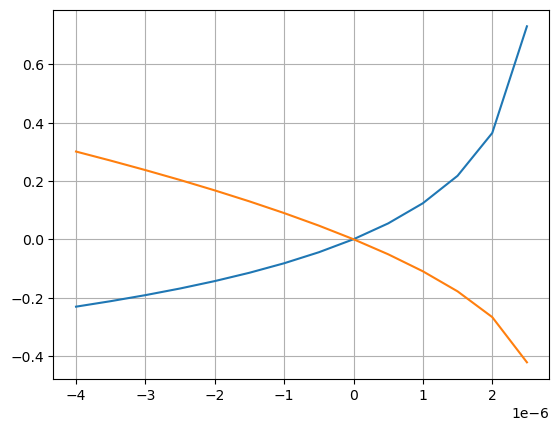

In [48]:
amp = np.arange(-4e-2, 4e-2, 5e-3)
std = 10e3
ratio1 = []
ratio2 = []
for a in amp:
    ds, dsa, dsm = eddy_reconstruction(
        L=25e3,
        std=std,
        dsl_amp=a,
    )
    ratio1.append(dsm.X_acc_cor / dsm.X_cor_ggd)
    ratio2.append(dsm.X_acc_ggd / dsm.X_cor_ggd)

plt.plot(amp / std, ratio1, label="X_acc_cor/X_cor_ggd")
plt.plot(amp / std, ratio2, label="X_acc_ggd/X_cor_ggd")
plt.grid()